# Notebook 13: Flight Trajectory & Hit Probability Prediction
## 비행궤적 산출 및 명중률 예측

This notebook demonstrates the full engagement simulation workflow:
1. 3-DOF trajectory computation with gravity, drag, and thrust
2. Multiple engagement geometry analysis (head-on, tail-chase, crossing)
3. Hit probability prediction via Monte Carlo with error budgets
4. CEP computation and statistical analysis

**Team relevance**: 비행궤적 산출 및 명중률 예측은 유도 조종 기법 및 성능 분석 팀의 핵심 업무

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse
from scipy.integrate import solve_ivp
from scipy import stats
from dataclasses import dataclass
from typing import Tuple, List, Optional

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print("Imports complete.")

Imports complete.


## 1. Missile & Target Models (유도탄/표적 모델)
### 1.1 3-DOF Point Mass Dynamics

The missile is modeled as a point mass in NED (North-East-Down) frame:

$$\dot{x} = V\cos\gamma\cos\psi$$
$$\dot{y} = V\cos\gamma\sin\psi$$
$$\dot{h} = V\sin\gamma$$
$$\dot{V} = (T - D)/m - g\sin\gamma$$
$$\dot{\gamma} = (L\cos\mu - mg\cos\gamma)/(mV)$$
$$\dot{\psi} = L\sin\mu/(mV\cos\gamma)$$

Where:
- $V$ = speed, $\gamma$ = flight path angle, $\psi$ = heading angle
- $T$ = thrust, $D$ = drag, $L$ = lift, $m$ = mass, $\mu$ = bank angle
- $g$ = gravitational acceleration

In [2]:
@dataclass
class MissileConfig:
    mass_initial: float = 150.0  # kg
    mass_final: float = 100.0    # kg (after burnout)
    thrust: float = 17500.0      # N
    burn_time: float = 2.2       # s
    S_ref: float = 0.0177        # m² (reference area, d=0.15m)
    CD_0: float = 0.3            # Zero-lift drag
    CD_alpha2: float = 8.0       # Induced drag coefficient
    CL_alpha: float = 15.0       # Lift slope (1/rad)
    a_max: float = 40 * 9.81     # Max lateral acceleration (40g)


@dataclass
class AtmosphereModel:
    """US 1976 Standard Atmosphere (simplified)."""

    def density(self, alt):
        """Air density at altitude (m)."""
        alt = max(float(alt), 0.0)
        if alt < 11000:
            T = 288.15 - 0.0065 * alt
            p = 101325 * (T / 288.15) ** 5.2561
        else:
            T = 216.65
            p = 22632 * np.exp(-9.81 * (alt - 11000) / (287.05 * T))
        return p / (287.05 * T)

    def speed_of_sound(self, alt):
        alt = max(float(alt), 0.0)
        if alt < 11000:
            T = 288.15 - 0.0065 * alt
        else:
            T = 216.65
        return np.sqrt(1.4 * 287.05 * T)


def missile_3dof(t, state, config, atm, guidance_accel):
    """3-DOF missile equations of motion.

    state: [x, y, alt, V, gamma, psi]
    guidance_accel: (a_pitch, a_yaw) commanded lateral accelerations
    """
    x, y, alt, V, gamma, psi = state

    # Mass (linear burn)
    if t < config.burn_time:
        frac = t / config.burn_time
        mass = config.mass_initial - (config.mass_initial - config.mass_final) * frac
        T = config.thrust
    else:
        mass = config.mass_final
        T = 0.0

    V = max(V, 1.0)  # Prevent divide-by-zero at very low speed

    # Atmosphere
    rho = atm.density(max(alt, 0))
    q = 0.5 * rho * V**2

    # Aerodynamics
    a_pitch, a_yaw = guidance_accel
    a_total = np.sqrt(a_pitch**2 + a_yaw**2)
    a_total = min(a_total, config.a_max)

    # Approximate angle of attack from required lift
    denom = q * config.S_ref * config.CL_alpha
    if denom > 1.0:
        alpha = mass * a_total / denom
        alpha = min(alpha, np.radians(25))
    else:
        alpha = 0.0

    # Forces
    CD = config.CD_0 + config.CD_alpha2 * alpha**2
    D = q * config.S_ref * CD
    L = mass * a_total  # Commanded lift equals required force

    # Bank angle to split lift between pitch and yaw
    if a_total > 1e-6:
        mu = np.arctan2(a_yaw, a_pitch)
    else:
        mu = 0.0

    g = 9.81

    # EOM
    dx = V * np.cos(gamma) * np.cos(psi)
    dy = V * np.cos(gamma) * np.sin(psi)
    dalt = V * np.sin(gamma)
    dV = (T - D) / mass - g * np.sin(gamma)

    cos_gamma = np.cos(gamma)
    if abs(cos_gamma) < 1e-6:
        cos_gamma = 1e-6 * np.sign(cos_gamma + 1e-10)

    dgamma = (L * np.cos(mu) - mass * g * cos_gamma) / (mass * V)
    dpsi = L * np.sin(mu) / (mass * V * cos_gamma)

    return [dx, dy, dalt, dV, dgamma, dpsi]


print("Missile model defined. Config:", MissileConfig())

Missile model defined. Config: MissileConfig(mass_initial=150.0, mass_final=100.0, thrust=17500.0, burn_time=2.2, S_ref=0.0177, CD_0=0.3, CD_alpha2=8.0, CL_alpha=15.0, a_max=392.40000000000003)


In [3]:
def proportional_navigation(missile_state, target_pos, target_vel, N=4.0):
    """3D True Proportional Navigation guidance law.

    Returns (a_pitch, a_yaw) acceleration commands in m/s².
    """
    x_m, y_m, alt_m, V_m, gamma_m, psi_m = missile_state

    # Missile position and velocity vectors (NED: x=North, y=East, z=Down)
    pos_m = np.array([x_m, y_m, -alt_m])
    vel_m = V_m * np.array([
        np.cos(gamma_m) * np.cos(psi_m),
        np.cos(gamma_m) * np.sin(psi_m),
        -np.sin(gamma_m)
    ])

    # Relative geometry
    R_vec = target_pos - pos_m
    R = np.linalg.norm(R_vec)
    if R < 1e-3:
        return (0.0, 0.0)
    R_hat = R_vec / R

    V_rel = target_vel - vel_m
    Vc = -np.dot(V_rel, R_hat)  # Closing velocity (positive when closing)

    # LOS rate vector: Omega = (R_vec × V_rel) / R²
    Omega = np.cross(R_vec, V_rel) / (R**2 + 1e-9)

    # TPN acceleration command: a_cmd = N * Vc * (Omega × R_hat)
    a_cmd = N * Vc * np.cross(Omega, R_hat)

    # Project to missile body pitch/yaw channels
    # Pitch (vertical): NED z-component (up positive => negate NED-down)
    a_pitch = -a_cmd[2]
    # Yaw (lateral): component perpendicular to heading in horizontal plane
    a_yaw = a_cmd[1] * np.cos(psi_m) - a_cmd[0] * np.sin(psi_m)

    return (float(a_pitch), float(a_yaw))


print("Proportional navigation guidance defined.")

Proportional navigation guidance defined.


In [4]:
def simulate_engagement(missile_init, target_init, target_vel,
                        config=None, N=4.0, dt=0.005, max_time=60.0,
                        target_maneuver=None):
    """Simulate complete engagement using RK4 integration.

    Parameters
    ----------
    missile_init : [x, y, alt, V, gamma, psi]  (m, m, m, m/s, rad, rad)
    target_init  : [x, y, z_ned]  NED coordinates (z positive down)
    target_vel   : [vx, vy, vz]   NED velocity (m/s)
    target_maneuver : callable(t) -> [ax, ay, az] NED accel (optional)

    Returns
    -------
    dict with trajectory history arrays
    """
    if config is None:
        config = MissileConfig()
    atm = AtmosphereModel()

    state = np.array(missile_init, dtype=float)
    target_pos = np.array(target_init, dtype=float)
    target_v = np.array(target_vel, dtype=float)

    history = {
        't': [], 'missile_pos': [], 'target_pos': [],
        'missile_state': [], 'a_cmd': [], 'range': [], 'Vc': []
    }

    t = 0.0
    prev_range = np.inf
    a_pitch, a_yaw = 0.0, 0.0  # Initial commands

    while t < max_time:
        # Missile NED position (alt is positive-up, NED z is positive-down)
        pos_m = np.array([state[0], state[1], -state[2]])
        R_vec = target_pos - pos_m
        R = np.linalg.norm(R_vec)

        # Missile velocity in NED
        vel_m = state[3] * np.array([
            np.cos(state[4]) * np.cos(state[5]),
            np.cos(state[4]) * np.sin(state[5]),
            -np.sin(state[4])
        ])
        Vc = -np.dot(target_v - vel_m, R_vec / (R + 1e-9))

        # Record state
        history['t'].append(t)
        history['missile_pos'].append(pos_m.copy())
        history['target_pos'].append(target_pos.copy())
        history['missile_state'].append(state.copy())
        history['a_cmd'].append((a_pitch, a_yaw))
        history['range'].append(R)
        history['Vc'].append(Vc)

        # Termination: past closest approach
        if R > prev_range * 1.01 and t > 1.0:
            break
        prev_range = R

        # Hit detection
        if R < 0.5:
            break

        # Ground impact
        if state[2] < 0 and t > 0.5:
            break

        # Guidance command
        a_pitch, a_yaw = proportional_navigation(state, target_pos, target_v, N=N)

        # Saturate to a_max
        a_mag = np.sqrt(a_pitch**2 + a_yaw**2)
        if a_mag > config.a_max:
            scale = config.a_max / a_mag
            a_pitch *= scale
            a_yaw *= scale

        # RK4 missile propagation
        def f(t_, s):
            return missile_3dof(t_, s, config, atm, (a_pitch, a_yaw))

        k1 = np.array(f(t, state))
        k2 = np.array(f(t + dt / 2, state + dt / 2 * k1))
        k3 = np.array(f(t + dt / 2, state + dt / 2 * k2))
        k4 = np.array(f(t + dt, state + dt * k3))
        state = state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

        # Target propagation
        if target_maneuver is not None:
            a_tgt = np.array(target_maneuver(t), dtype=float)
            target_v = target_v + a_tgt * dt
        target_pos = target_pos + target_v * dt

        t += dt

    # Convert lists to arrays
    for k in history:
        history[k] = np.array(history[k])

    history['miss_distance'] = float(history['range'][-1]) if len(history['range']) > 0 else np.inf
    history['flight_time'] = float(history['t'][-1]) if len(history['t']) > 0 else 0.0
    return history


print("Engagement simulator defined.")

Engagement simulator defined.


## 2. Trajectory Computation (비행궤적 산출)
### 2.1 Baseline Engagement Scenarios

Four representative engagement geometries are simulated:

| Scenario | Description | Closing Speed |
|----------|-------------|---------------|
| **Head-On (정면)** | Missile & target approach head-on | ~980 m/s |
| **Tail-Chase (추미)** | Missile chases target from behind | ~430 m/s |
| **Crossing (교차)** | 90° crossing angle | ~730 m/s |
| **Diving (다이빙)** | Missile above, target below | ~800 m/s |

All scenarios use TPN (True Proportional Navigation) with N = 4.

In [5]:
# ── Scenario definitions ────────────────────────────────────────────────────
# missile_init: [x(m), y(m), alt(m), V(m/s), gamma(rad), psi(rad)]
# target_init : [x_ned, y_ned, z_ned]  (z_ned = -alt)
# target_vel  : [vx, vy, vz] NED (m/s)

scenarios = {
    'Head-On\n(정면 교전)': dict(
        missile_init=[0, 0, 5000, 680, 0, 0],          # heading North
        target_init =[20000, 0, -5000],                 # 20 km North, same alt
        target_vel  =[-300, 0, 0],                      # heading South
    ),
    'Tail-Chase\n(추미 교전)': dict(
        missile_init=[0, 0, 5000, 680, 0, 0],           # heading North
        target_init =[12000, 0, -5000],                 # 12 km ahead
        target_vel  =[250, 0, 0],                       # fleeing North
    ),
    'Crossing\n(교차 교전)': dict(
        missile_init=[0, 0, 5000, 680, 0, np.radians(30)],  # heading NE
        target_init =[15000, -8000, -5000],
        target_vel  =[0, 300, 0],                       # heading East
    ),
    'Diving\n(다이빙 교전)': dict(
        missile_init=[0, 0, 8000, 680, np.radians(-5), 0],  # slightly nose-down
        target_init =[18000, 0, -3000],                 # target at lower alt
        target_vel  =[-280, 0, 0],
    ),
}

# ── Run simulations ──────────────────────────────────────────────────────────
results = {}
print(f"{'Scenario':<22} {'Miss Dist (m)':>14} {'Flight Time (s)':>16}")
print("-" * 54)
for name, sc in scenarios.items():
    label = name.replace('\n', ' ')
    res = simulate_engagement(
        sc['missile_init'], sc['target_init'], sc['target_vel'],
        N=4.0, dt=0.01, max_time=80.0
    )
    results[name] = res
    print(f"{label:<22} {res['miss_distance']:>14.2f} {res['flight_time']:>16.2f}")

Scenario                Miss Dist (m)  Flight Time (s)
------------------------------------------------------
Head-On (정면 교전)                 15.37            17.48


Tail-Chase (추미 교전)               2.63            20.82


Crossing (교차 교전)                 9.90            20.54


Diving (다이빙 교전)                 13.60            16.31


/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/80393071.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/80393071.py:26: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/80393071.py:26: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/80393071.py:26: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/80393071.py:26: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21

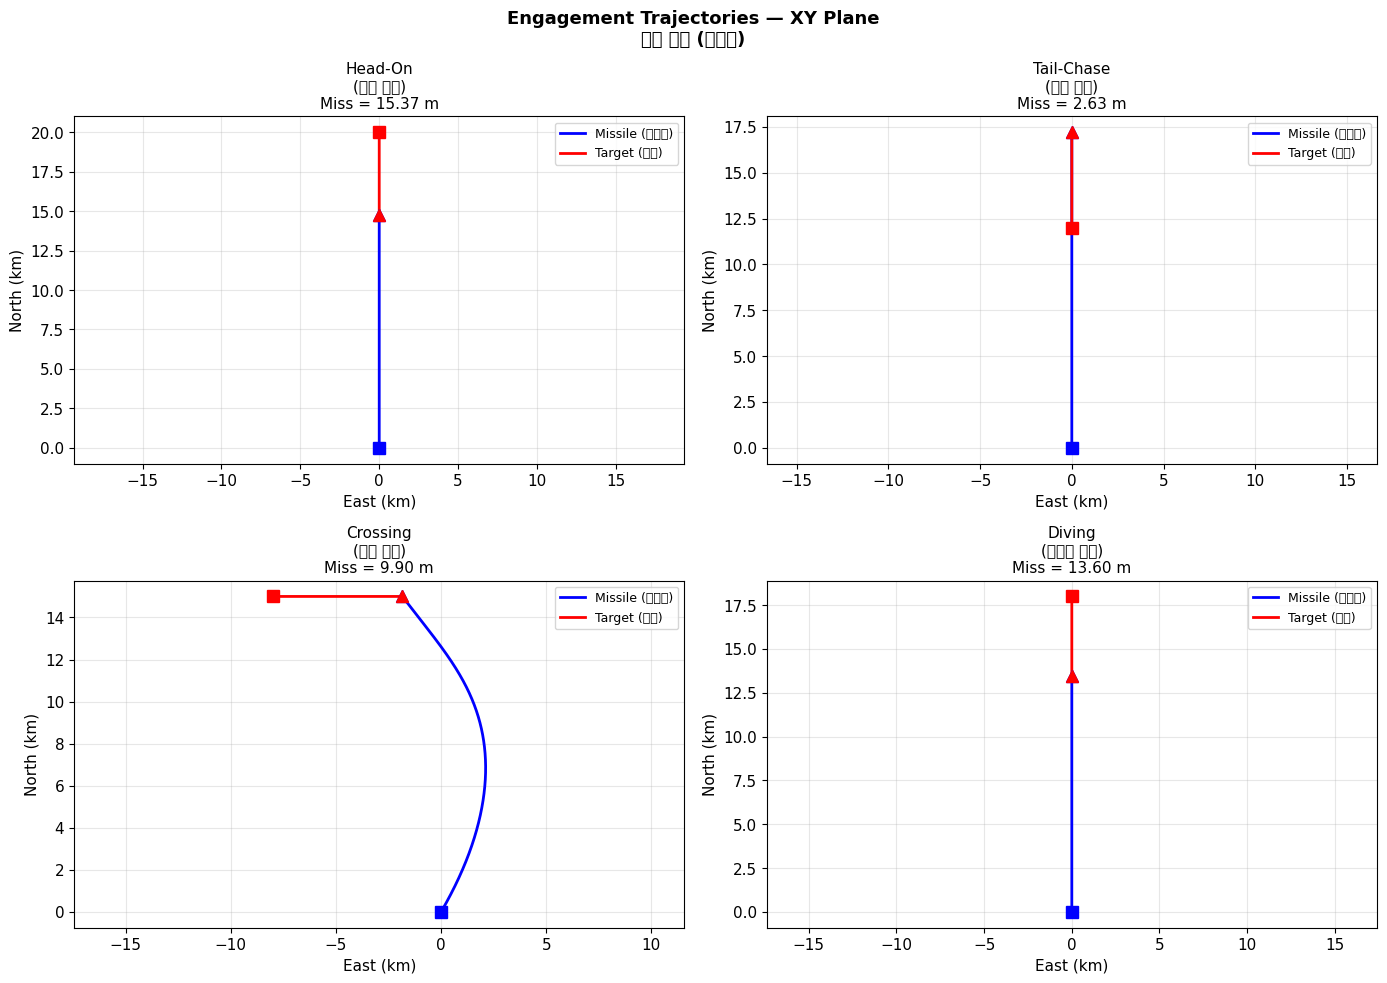

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    mp = res['missile_pos']   # shape (N, 3): [x_ned, y_ned, z_ned]
    tp = res['target_pos']

    # x=North, y=East in NED
    ax.plot(mp[:, 1] / 1000, mp[:, 0] / 1000, 'b-', lw=2, label='Missile (유도탄)')
    ax.plot(tp[:, 1] / 1000, tp[:, 0] / 1000, 'r-', lw=2, label='Target (표적)')

    # Start / end markers
    ax.plot(mp[0, 1] / 1000, mp[0, 0] / 1000, 'bs', ms=8)
    ax.plot(mp[-1, 1] / 1000, mp[-1, 0] / 1000, 'b^', ms=8)
    ax.plot(tp[0, 1] / 1000, tp[0, 0] / 1000, 'rs', ms=8)
    ax.plot(tp[-1, 1] / 1000, tp[-1, 0] / 1000, 'r^', ms=8)

    miss = res['miss_distance']
    ax.set_title(f"{name}\nMiss = {miss:.2f} m", fontsize=11)
    ax.set_xlabel('East (km)')
    ax.set_ylabel('North (km)')
    ax.legend(fontsize=9)
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle('Engagement Trajectories — XY Plane\n교전 궤적 (수평면)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/1885839567.py:35: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/1885839567.py:35: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/1885839567.py:35: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/1885839567.py:35: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/1885839567.py:35: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ip

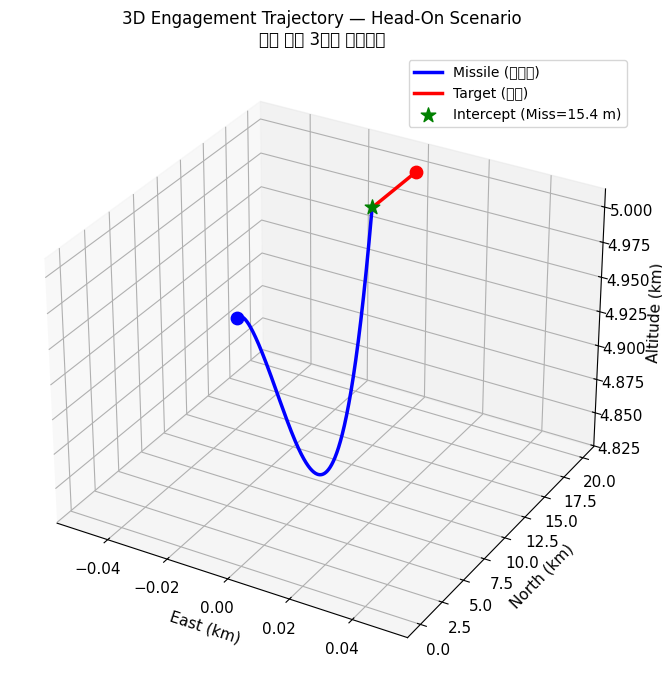

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Use head-on scenario for 3D viz
res3d = results['Head-On\n(정면 교전)']
mp = res3d['missile_pos']
tp = res3d['target_pos']

# Convert NED to (North, East, Alt): alt = -z_ned
north_m = mp[:, 0] / 1000
east_m  = mp[:, 1] / 1000
alt_m   = -mp[:, 2] / 1000

north_t = tp[:, 0] / 1000
east_t  = tp[:, 1] / 1000
alt_t   = -tp[:, 2] / 1000

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(east_m, north_m, alt_m, 'b-', lw=2.5, label='Missile (유도탄)')
ax.plot(east_t, north_t, alt_t, 'r-', lw=2.5, label='Target (표적)')

# Start markers
ax.scatter(*[east_m[0]], *[north_m[0]], *[alt_m[0]], c='b', s=80, marker='o', zorder=5)
ax.scatter(*[east_t[0]], *[north_t[0]], *[alt_t[0]], c='r', s=80, marker='o', zorder=5)
# Intercept marker
ax.scatter(*[east_m[-1]], *[north_m[-1]], *[alt_m[-1]], c='g', s=120, marker='*',
           zorder=5, label=f'Intercept (Miss={res3d["miss_distance"]:.1f} m)')

ax.set_xlabel('East (km)')
ax.set_ylabel('North (km)')
ax.set_zlabel('Altitude (km)')
ax.set_title('3D Engagement Trajectory — Head-On Scenario\n정면 교전 3차원 비행궤적', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3176119215.py:45: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3176119215.py:45: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3176119215.py:45: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3176119215.py:45: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3176119215.py:45: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykern

/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB

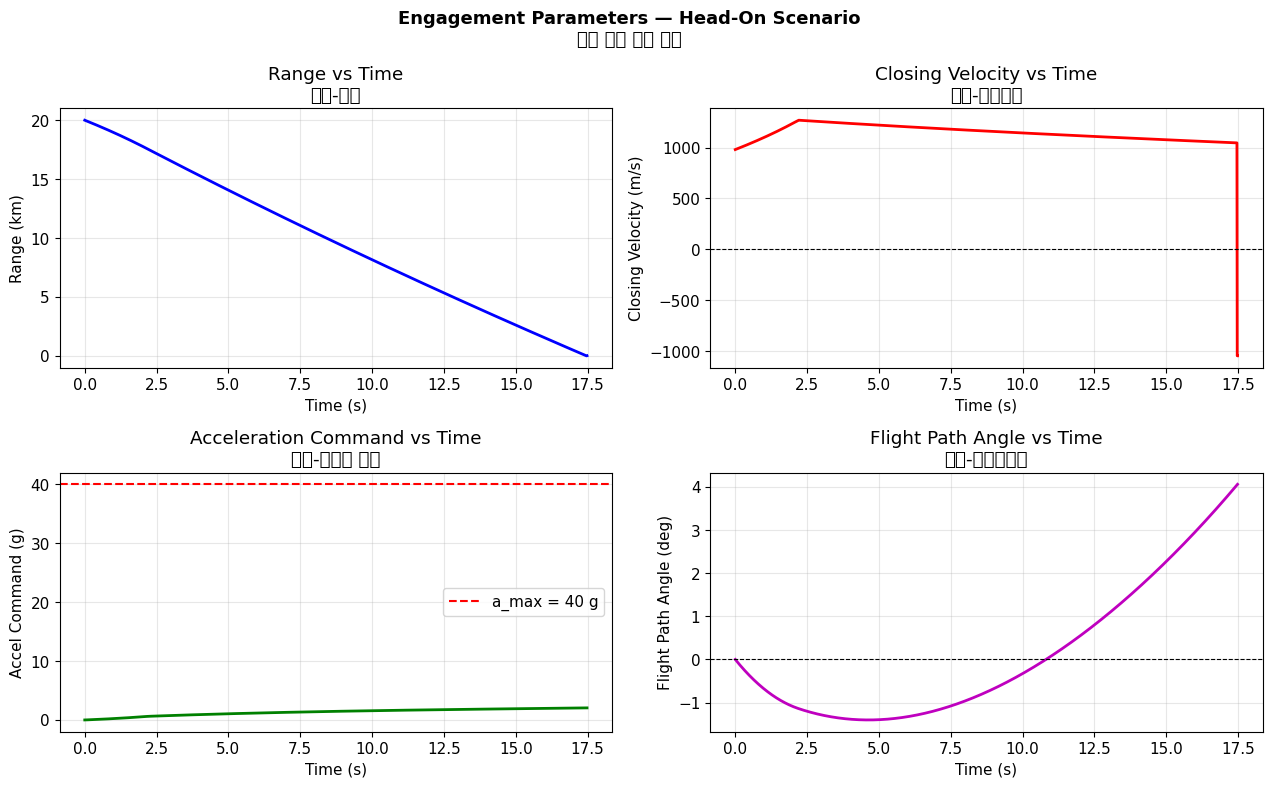

In [8]:
res_ho = results['Head-On\n(정면 교전)']
t   = res_ho['t']
rng = res_ho['range']
Vc  = res_ho['Vc']
states = res_ho['missile_state']   # [x, y, alt, V, gamma, psi]
acmds  = res_ho['a_cmd']           # (a_pitch, a_yaw)

# Acceleration magnitude (m/s² -> g)
a_mag_g = np.sqrt(acmds[:, 0]**2 + acmds[:, 1]**2) / 9.81

# Flight path angle (deg)
gamma_deg = np.degrees(states[:, 4])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Range vs time
axes[0, 0].plot(t, rng / 1000, 'b-', lw=2)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Range (km)')
axes[0, 0].set_title('Range vs Time\n시간-거리')

# Closing velocity vs time
axes[0, 1].plot(t, Vc, 'r-', lw=2)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Closing Velocity (m/s)')
axes[0, 1].set_title('Closing Velocity vs Time\n시간-접근속도')
axes[0, 1].axhline(0, color='k', lw=0.8, ls='--')

# Acceleration command magnitude vs time
axes[1, 0].plot(t, a_mag_g, 'g-', lw=2)
axes[1, 0].axhline(40, color='r', lw=1.5, ls='--', label='a_max = 40 g')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Accel Command (g)')
axes[1, 0].set_title('Acceleration Command vs Time\n시간-가속도 명령')
axes[1, 0].legend()

# Flight path angle vs time
axes[1, 1].plot(t, gamma_deg, 'm-', lw=2)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Flight Path Angle (deg)')
axes[1, 1].set_title('Flight Path Angle vs Time\n시간-비행경로각')
axes[1, 1].axhline(0, color='k', lw=0.8, ls='--')

fig.suptitle('Engagement Parameters — Head-On Scenario\n정면 교전 교전 변수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Maneuvering Target Analysis (기동 표적 분석)
### 3.1 Target Maneuver Profiles

Four representative target evasion maneuvers are evaluated against TPN guidance:

| Maneuver | Description | Peak Lateral Accel |
|----------|-------------|-------------------|
| **Constant g-turn (일정 기동)** | Sustained lateral pull at onset | 5 g |
| **Weaving (위빙 기동)** | Sinusoidal lateral oscillation | ±4 g |
| **S-maneuver (S자 기동)** | Two-phase S-shaped turn | 5 g |
| **Pop-up (팝업 기동)** | Late vertical pull-up | 6 g |

Higher maneuver frequency and late onset are most challenging for proportional navigation.

/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/4129848174.py:54: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/4129848174.py:54: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/4129848174.py:54: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/4129848174.py:54: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/4129848174.py:54: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipyker

/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}

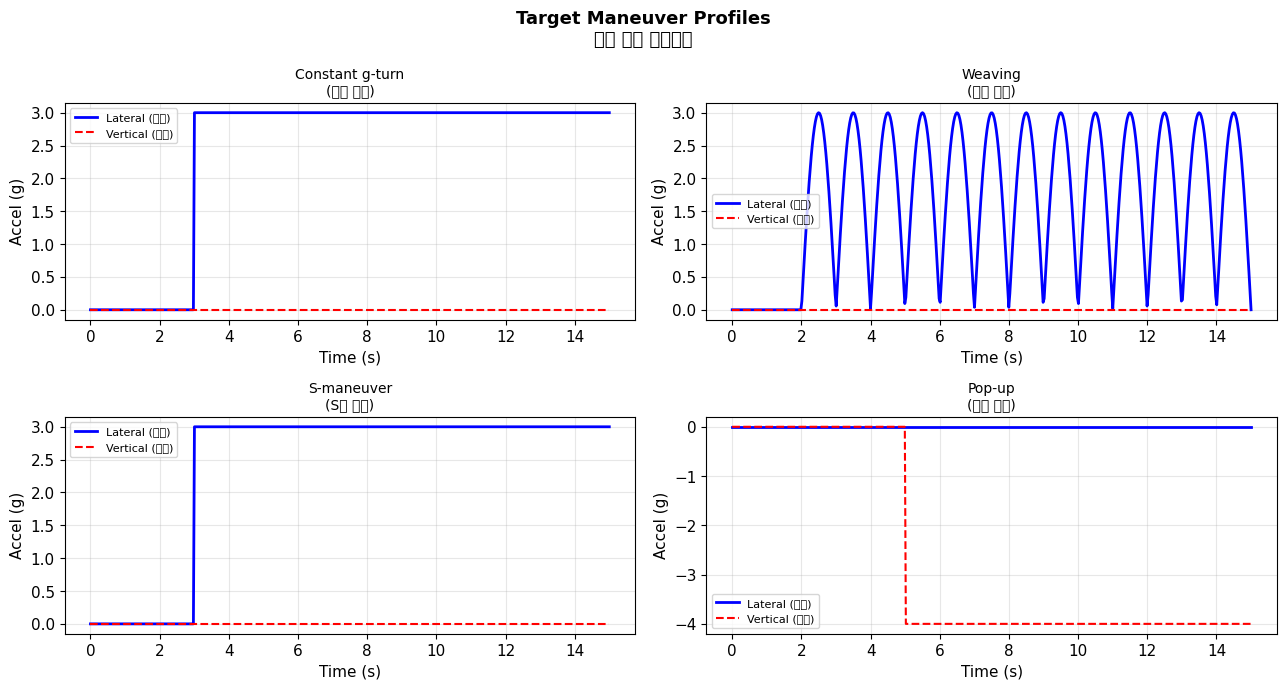

In [9]:
g = 9.81  # m/s²

def maneuver_constant_gturn(t, onset=3.0, aT=3*9.81):
    """일정 기동: Constant lateral g-turn starting at onset time (3 g)."""
    if t >= onset:
        return [0.0, aT, 0.0]   # lateral (East) acceleration in NED
    return [0.0, 0.0, 0.0]

def maneuver_weaving(t, onset=2.0, aT=3*9.81, freq=0.5):
    """위빙 기동: Sinusoidal lateral weaving maneuver (±3 g, 0.5 Hz)."""
    if t >= onset:
        return [0.0, aT * np.sin(2 * np.pi * freq * (t - onset)), 0.0]
    return [0.0, 0.0, 0.0]

def maneuver_s_turn(t, onset=3.0, aT=3*9.81, half_period=2.5):
    """S자 기동: S-shaped two-phase maneuver (3 g)."""
    if t >= onset:
        phase = t - onset
        if phase < half_period:
            return [0.0, aT, 0.0]
        else:
            return [0.0, -aT, 0.0]
    return [0.0, 0.0, 0.0]

def maneuver_popup(t, onset=5.0, aT=4*9.81):
    """팝업 기동: Late vertical pull-up at t=5 s (4 g upward)."""
    if t >= onset:
        return [0.0, 0.0, -aT]   # NED z: negative = upward
    return [0.0, 0.0, 0.0]

# Preview maneuver profiles
t_preview = np.linspace(0, 15, 500)
maneuvers = {
    'Constant g-turn\n(일정 기동)': maneuver_constant_gturn,
    'Weaving\n(위빙 기동)':         maneuver_weaving,
    'S-maneuver\n(S자 기동)':       maneuver_s_turn,
    'Pop-up\n(팝업 기동)':          maneuver_popup,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()
for ax, (name, fn) in zip(axes, maneuvers.items()):
    accs = np.array([fn(t) for t in t_preview])
    vertical = accs[:, 2] / g
    horiz    = np.sqrt(accs[:, 0]**2 + accs[:, 1]**2) / g
    ax.plot(t_preview, horiz,    'b-', lw=2, label='Lateral (수평)')
    ax.plot(t_preview, vertical, 'r--', lw=1.5, label='Vertical (수직)')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Accel (g)')
    ax.legend(fontsize=8)

fig.suptitle('Target Maneuver Profiles\n표적 기동 프로파일', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Maneuver                        Miss Distance (m)  Flight Time (s)
------------------------------------------------------------------
Constant g-turn (일정 기동)                      6.07            10.24
Weaving (위빙 기동)                              5.88            10.15


S-maneuver (S자 기동)                          13.57            10.17
Pop-up (팝업 기동)                               8.69            10.25


/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2235248998.py:45: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2235248998.py:45: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2235248998.py:45: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2235248998.py:45: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2235248998.py:45: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipyker

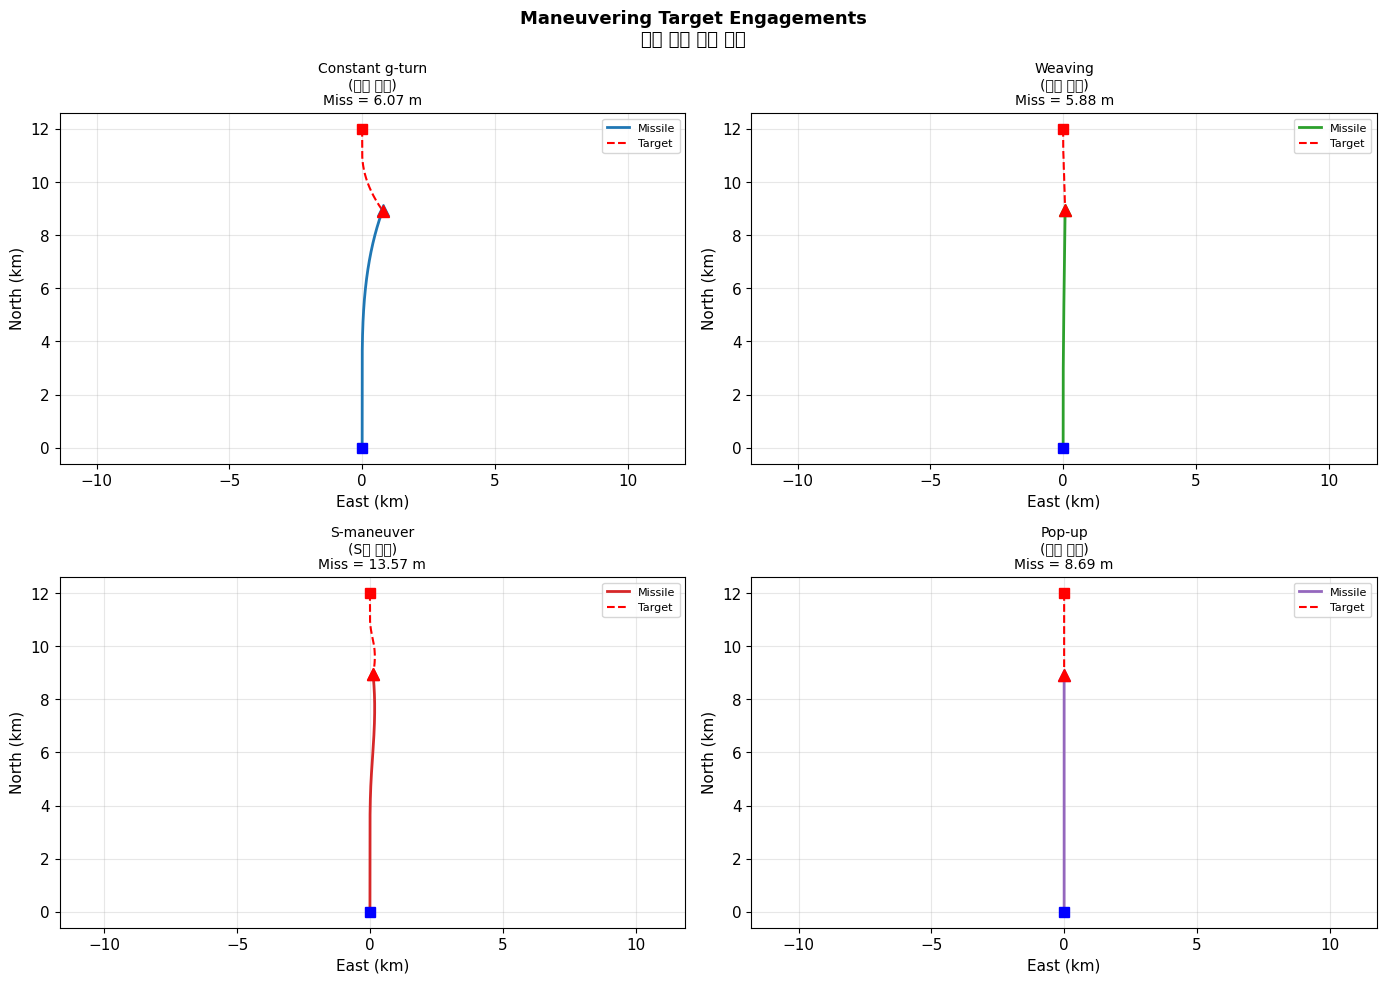

In [10]:
# Head-on baseline geometry for all maneuver tests
# Shorter range (12 km) so missile can intercept even with large target maneuvers
base_missile = [0, 0, 5000, 680, 0, 0]
base_target  = [12000, 0, -5000]
base_tvel    = [-300, 0, 0]

maneuver_results = {}
print(f"{'Maneuver':<30} {'Miss Distance (m)':>18} {'Flight Time (s)':>16}")
print("-" * 66)

for name, fn in maneuvers.items():
    res = simulate_engagement(
        base_missile, base_target, base_tvel,
        N=4.0, dt=0.01, max_time=40.0,
        target_maneuver=fn
    )
    maneuver_results[name] = res
    label = name.replace('\n', ' ')
    print(f"{label:<30} {res['miss_distance']:>18.2f} {res['flight_time']:>16.2f}")

# ── Trajectory plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors_m = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']

for ax, (name, res), cm in zip(axes, maneuver_results.items(), colors_m):
    mp = res['missile_pos']
    tp = res['target_pos']

    ax.plot(mp[:, 1] / 1000, mp[:, 0] / 1000, color=cm, lw=2, label='Missile')
    ax.plot(tp[:, 1] / 1000, tp[:, 0] / 1000, 'r--', lw=1.5, label='Target')
    ax.plot(mp[0, 1] / 1000, mp[0, 0] / 1000, 'bs', ms=7)
    ax.plot(mp[-1, 1] / 1000, mp[-1, 0] / 1000, color=cm, marker='^', ms=9, ls='none')
    ax.plot(tp[0, 1] / 1000, tp[0, 0] / 1000, 'rs', ms=7)
    ax.plot(tp[-1, 1] / 1000, tp[-1, 0] / 1000, 'r^', ms=9)

    miss = res['miss_distance']
    ax.set_title(f"{name}\nMiss = {miss:.2f} m", fontsize=10)
    ax.set_xlabel('East (km)')
    ax.set_ylabel('North (km)')
    ax.legend(fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle('Maneuvering Target Engagements\n기동 표적 교전 궤적', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Hit Probability Prediction (명중률 예측)
### 4.1 Monte Carlo Simulation Setup

Hit probability is estimated by propagating a realistic error budget through many independent engagement simulations.

**Error sources modeled:**

| Source | Parameter | Distribution |
|--------|-----------|--------------|
| Seeker LOS noise | σ = 3 mrad | Gaussian |
| Launch heading error | σ = 1° | Gaussian |
| Initial altitude error | σ = 50 m | Gaussian |
| Initial speed error | σ = 5 m/s | Gaussian |
| Target maneuver magnitude | [0, 9g] | Uniform |
| Target maneuver onset | [30%, 80%] of flight | Uniform |
| Maneuver direction | ±1 | Discrete uniform |

**Hit criterion**: miss distance < 5 m (proximity fuze radius)

**CEP** (Circular Error Probable / 원형공산오차): The radius within which 50% of intercepts fall.

In [11]:
def monte_carlo_engagement(n_runs, scenario='head_on', N=4.0, seed=42, dt=0.05):
    """Run Monte Carlo engagement simulations.

    Returns (miss_distances, miss_vectors).
    dt=0.05 s gives acceptable accuracy for CEP statistics while keeping runtime short.
    Use dt=0.01 for higher-fidelity individual trajectory analysis.
    """
    rng = np.random.RandomState(seed)
    miss_distances = []
    miss_vectors   = []  # (lateral, vertical) miss for CEP scatter

    for i in range(n_runs):
        # ── Dispersion of initial conditions ────────────────────────────
        heading_err  = rng.normal(0, np.radians(1.0))
        alt_err      = rng.normal(0, 50.0)     # m
        speed_err    = rng.normal(0, 5.0)      # m/s
        seeker_noise = rng.normal(0, 3e-3)     # rad (equivalent heading perturbation)

        # ── Target maneuver randomization ───────────────────────────────
        aT_mag              = rng.uniform(0, 9.0 * 9.81)
        maneuver_onset_frac = rng.uniform(0.3, 0.8)
        maneuver_dir        = rng.choice([-1, 1])
        maneuver_axis       = rng.choice([1, 2])    # 1=lateral(East), 2=vertical(Up=-NED_z)

        # ── Scenario-specific initial conditions ────────────────────────
        if scenario == 'head_on':
            missile_init = [0, 0, 5000 + alt_err, 680 + speed_err,
                            heading_err, seeker_noise]
            target_init  = [20000, 0, -5000]
            target_vel   = [-300, 0, 0]
            tf_est       = 20000 / 980.0

        elif scenario == 'tail_chase':
            missile_init = [0, 0, 5000 + alt_err, 680 + speed_err,
                            heading_err, seeker_noise]
            target_init  = [12000, 0, -5000]
            target_vel   = [250, 0, 0]
            tf_est       = 12000 / 430.0

        elif scenario == 'crossing':
            missile_init = [0, 0, 5000 + alt_err, 680 + speed_err,
                            heading_err, np.radians(30) + seeker_noise]
            target_init  = [15000, -8000, -5000]
            target_vel   = [0, 300, 0]
            tf_est       = 20000 / 730.0

        else:
            missile_init = [0, 0, 5000 + alt_err, 680 + speed_err,
                            heading_err, seeker_noise]
            target_init  = [20000, 0, -5000]
            target_vel   = [-300, 0, 0]
            tf_est       = 20000 / 980.0

        onset_time = maneuver_onset_frac * tf_est

        def make_maneuver(onset, axis, direction, magnitude):
            def maneuver(t):
                if t > onset:
                    a = [0.0, 0.0, 0.0]
                    a[axis] = direction * magnitude
                    return a
                return [0.0, 0.0, 0.0]
            return maneuver

        maneuver_fn = make_maneuver(onset_time, maneuver_axis, maneuver_dir, aT_mag)

        try:
            result = simulate_engagement(
                missile_init, target_init, target_vel,
                N=N, target_maneuver=maneuver_fn, dt=dt, max_time=80
            )
            md = result['miss_distance']
            miss_distances.append(md)

            # Miss vector: last relative position (lateral East, vertical Up)
            if len(result['missile_pos']) > 0 and len(result['target_pos']) > 0:
                delta = result['target_pos'][-1] - result['missile_pos'][-1]
                miss_vectors.append((delta[1], -delta[2]))
            else:
                miss_vectors.append((0.0, 0.0))

        except Exception:
            miss_distances.append(np.inf)
            miss_vectors.append((np.inf, np.inf))

    return np.array(miss_distances), np.array(miss_vectors)


print("Monte Carlo function defined.")

Monte Carlo function defined.


In [12]:
print("Running Monte Carlo simulations...")
print("(n=300, dt=0.05 s — increase n to 1000+ and reduce dt for production accuracy)\n")

n_mc = 300  # Use 1000+ with dt=0.01 for production accuracy

scenarios_mc = ['head_on', 'tail_chase', 'crossing']
scenario_labels = {
    'head_on':   'Head-On (정면)',
    'tail_chase':'Tail-Chase (추미)',
    'crossing':  'Crossing (교차)',
}

mc_results  = {}   # miss distances
mc_vectors  = {}   # miss vectors for CEP scatter
mc_stats    = {}   # statistics dict

HIT_RADIUS = 5.0   # m — proximity fuze radius

for sc in scenarios_mc:
    name = scenario_labels[sc]
    miss, vecs = monte_carlo_engagement(n_mc, scenario=sc, N=4.0, seed=42, dt=0.05)
    mc_results[name] = miss
    mc_vectors[name] = vecs

    valid = miss[miss < 500]   # exclude diverged runs (> 500 m treated as no-intercept)
    cep   = np.percentile(valid, 50)  if len(valid) > 0 else np.nan
    p95   = np.percentile(valid, 95)  if len(valid) > 0 else np.nan
    p_hit = np.mean(miss < HIT_RADIUS)

    mc_stats[name] = {'cep': cep, 'p95': p95, 'p_hit': p_hit,
                      'n_valid': len(valid), 'miss': valid}

    print(f"{name}:")
    print(f"  CEP (50th pct):       {cep:6.2f} m")
    print(f"  95th percentile:      {p95:6.2f} m")
    print(f"  Hit probability:      {p_hit:6.1%}  (miss < {HIT_RADIUS} m)")
    print(f"  Valid runs:           {len(valid)}/{n_mc}")
    print()

Running Monte Carlo simulations...
(n=300, dt=0.05 s — increase n to 1000+ and reduce dt for production accuracy)



Head-On (정면):
  CEP (50th pct):        44.29 m
  95th percentile:      151.70 m
  Hit probability:        1.7%  (miss < 5.0 m)
  Valid runs:           257/300



Tail-Chase (추미):
  CEP (50th pct):        19.27 m
  95th percentile:       76.33 m
  Hit probability:        5.0%  (miss < 5.0 m)
  Valid runs:           236/300



Crossing (교차):
  CEP (50th pct):        43.15 m
  95th percentile:       75.68 m
  Hit probability:        1.3%  (miss < 5.0 m)
  Valid runs:           261/300



/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3003444736.py:47: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3003444736.py:47: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3003444736.py:47: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3003444736.py:47: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3003444736.py:47: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipyke

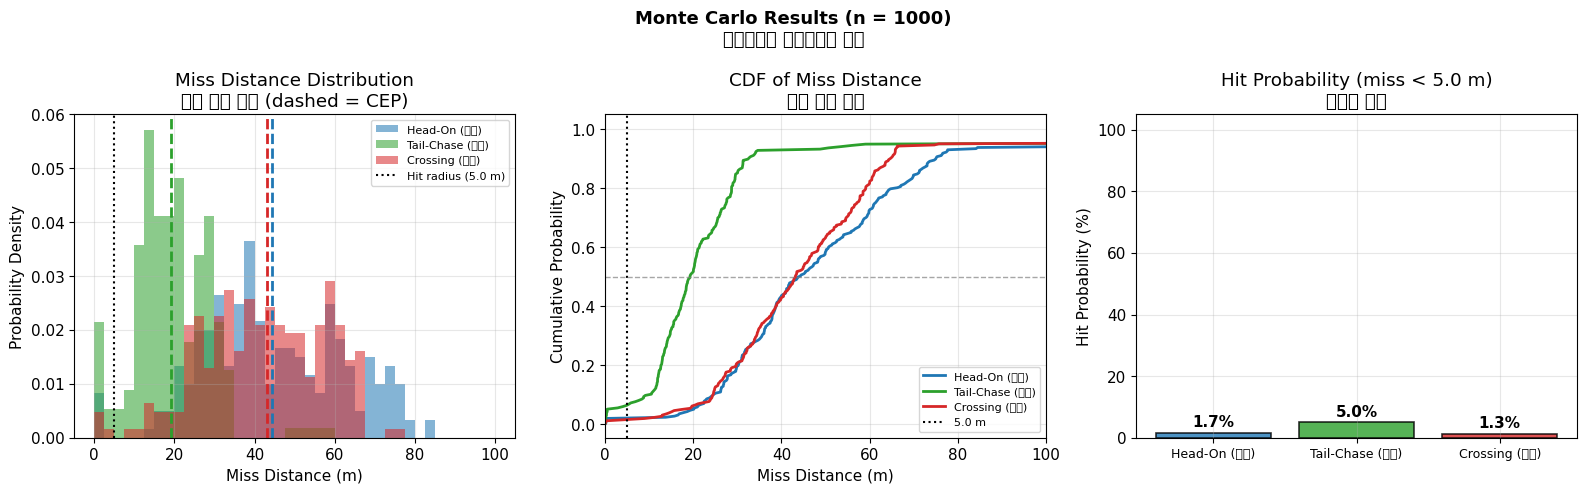

In [13]:
colors_sc = ['#1f77b4', '#2ca02c', '#d62728']
names_sc   = list(mc_stats.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Miss distance histograms ───────────────────────────────────────
ax = axes[0]
for name, col in zip(names_sc, colors_sc):
    valid = mc_stats[name]['miss']
    ax.hist(valid, bins=40, range=(0, min(valid.max(), 100)),
            alpha=0.55, color=col, label=name, density=True)
    cep = mc_stats[name]['cep']
    ax.axvline(cep, color=col, lw=2, ls='--')
ax.axvline(HIT_RADIUS, color='k', lw=1.5, ls=':', label=f'Hit radius ({HIT_RADIUS} m)')
ax.set_xlabel('Miss Distance (m)')
ax.set_ylabel('Probability Density')
ax.set_title('Miss Distance Distribution\n명중 오차 분포 (dashed = CEP)')
ax.legend(fontsize=8)

# ── Panel 2: CDF curves ─────────────────────────────────────────────────────
ax = axes[1]
for name, col in zip(names_sc, colors_sc):
    valid = np.sort(mc_stats[name]['miss'])
    cdf   = np.arange(1, len(valid) + 1) / len(valid)
    ax.plot(valid, cdf, color=col, lw=2, label=name)
ax.axvline(HIT_RADIUS, color='k', lw=1.5, ls=':', label=f'{HIT_RADIUS} m')
ax.axhline(0.50, color='gray', lw=1, ls='--', alpha=0.7)
ax.set_xlabel('Miss Distance (m)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Miss Distance\n누적 분포 함수')
ax.set_xlim(0, min(100, max(mc_stats[n]['miss'].max() for n in names_sc)))
ax.legend(fontsize=8)

# ── Panel 3: Hit probability bar chart ──────────────────────────────────────
ax = axes[2]
p_hits = [mc_stats[n]['p_hit'] * 100 for n in names_sc]
bars = ax.bar(names_sc, p_hits, color=colors_sc, alpha=0.8, edgecolor='k', lw=1.2)
for bar, ph in zip(bars, p_hits):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.0,
            f'{ph:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Hit Probability (%)')
ax.set_title(f'Hit Probability (miss < {HIT_RADIUS} m)\n명중률 비교')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Monte Carlo Results (n = 1000)\n몬테카를로 시뮬레이션 결과', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. CEP Analysis (원형공산오차 분석)

**CEP (Circular Error Probable / 원형공산오차)** is the radius of the circle centered on the aim point within which 50% of all intercepts land.

$$P(\text{miss} \leq \text{CEP}) = 0.50$$

For a bivariate Gaussian miss distribution with equal standard deviations $\sigma$:
$$\text{CEP} \approx 1.1774 \cdot \sigma$$

The scatter plot in the miss plane (lateral vs. vertical components) reveals:
- **Bias**: systematic offset from center → guidance or navigation error
- **Dispersion shape**: circular vs. elliptical → equal vs. unequal error sources
- The 50% probability ellipse is the CEP contour

/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/

/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/2254194519.py:74: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/

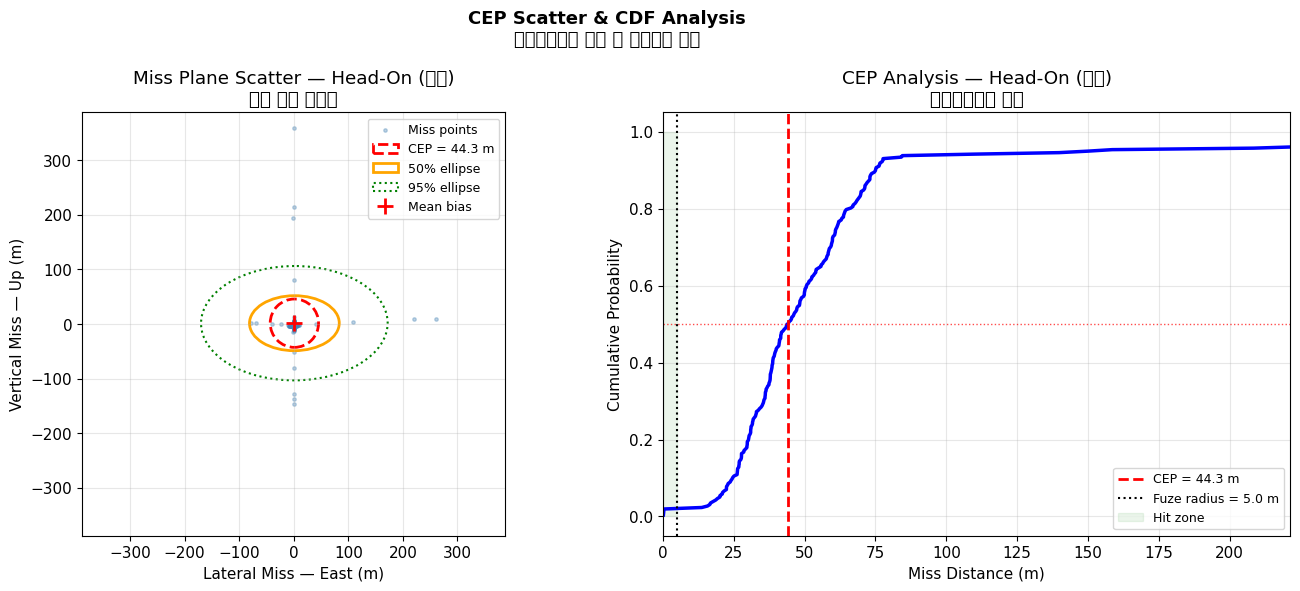


Bias: lateral = 1.29 m,  vertical = 1.63 m
σ_lateral = 69.69 m,  σ_vertical = 42.70 m
CEP (scalar miss, 50th pct) = 44.29 m


In [14]:
# Use head-on scenario miss vectors
sc_name  = 'Head-On (정면)'
miss_all = mc_results[sc_name]
vecs_all = mc_vectors[sc_name]

# Filter valid (non-diverged) runs
valid_mask = miss_all < 500
lat  = vecs_all[valid_mask, 0]   # lateral (East) miss component
vert = vecs_all[valid_mask, 1]   # vertical (Up) miss component

# CEP from scalar miss distances
cep_val = mc_stats[sc_name]['cep']

# Fit covariance ellipse
cov = np.cov(lat, vert)
eigvals, eigvecs = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
# 50% probability ellipse scale factor for bivariate normal: chi2(2, 0.50)^0.5
from scipy.stats import chi2 as chi2_dist
scale_50 = np.sqrt(chi2_dist.ppf(0.50, df=2))
scale_95 = np.sqrt(chi2_dist.ppf(0.95, df=2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: scatter + CEP circle + ellipse ────────────────────────────────────
ax = axes[0]
ax.scatter(lat, vert, s=6, alpha=0.35, color='steelblue', label='Miss points')

# CEP circle (50% radius)
circle_cep = Circle((np.mean(lat), np.mean(vert)), cep_val,
                     fill=False, color='red', lw=2, ls='--', label=f'CEP = {cep_val:.1f} m')
ax.add_patch(circle_cep)

# 50% probability ellipse from covariance
w50 = 2 * scale_50 * np.sqrt(eigvals[-1])
h50 = 2 * scale_50 * np.sqrt(eigvals[0])
ellipse_50 = Ellipse((np.mean(lat), np.mean(vert)), width=w50, height=h50,
                      angle=angle, fill=False, color='orange', lw=2, label='50% ellipse')
ax.add_patch(ellipse_50)

# 95% probability ellipse
w95 = 2 * scale_95 * np.sqrt(eigvals[-1])
h95 = 2 * scale_95 * np.sqrt(eigvals[0])
ellipse_95 = Ellipse((np.mean(lat), np.mean(vert)), width=w95, height=h95,
                      angle=angle, fill=False, color='green', lw=1.5, ls=':', label='95% ellipse')
ax.add_patch(ellipse_95)

ax.plot(np.mean(lat), np.mean(vert), 'r+', ms=12, mew=2, label='Mean bias')
ax.set_aspect('equal')
lim = max(cep_val * 3, np.percentile(np.abs(lat), 98), np.percentile(np.abs(vert), 98))
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Lateral Miss — East (m)')
ax.set_ylabel('Vertical Miss — Up (m)')
ax.set_title(f'Miss Plane Scatter — {sc_name}\n명중 오차 산포도')
ax.legend(fontsize=9)

# ── Right: radial miss CDF with CEP annotation ──────────────────────────────
ax = axes[1]
sorted_miss = np.sort(miss_all[valid_mask])
cdf = np.arange(1, len(sorted_miss) + 1) / len(sorted_miss)
ax.plot(sorted_miss, cdf, 'b-', lw=2.5)
ax.axvline(cep_val, color='red', lw=2, ls='--', label=f'CEP = {cep_val:.1f} m')
ax.axhline(0.50, color='red', lw=1, ls=':', alpha=0.7)
ax.axvline(HIT_RADIUS, color='k', lw=1.5, ls=':', label=f'Fuze radius = {HIT_RADIUS} m')
ax.fill_betweenx([0, 1], 0, HIT_RADIUS, alpha=0.08, color='green', label='Hit zone')
ax.set_xlabel('Miss Distance (m)')
ax.set_ylabel('Cumulative Probability')
ax.set_title(f'CEP Analysis — {sc_name}\n원형공산오차 분석')
ax.set_xlim(0, min(sorted_miss[-1], cep_val * 5))
ax.legend(fontsize=9)

fig.suptitle('CEP Scatter & CDF Analysis\n원형공산오차 산포 및 누적분포 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBias: lateral = {np.mean(lat):.2f} m,  vertical = {np.mean(vert):.2f} m")
print(f"σ_lateral = {np.std(lat):.2f} m,  σ_vertical = {np.std(vert):.2f} m")
print(f"CEP (scalar miss, 50th pct) = {cep_val:.2f} m")

## 6. Navigation Ratio Trade Study (유도 이득 트레이드 스터디)

The navigation ratio $N$ is the single most important tuning parameter in Proportional Navigation.

**Trade-offs:**
- **Low N (< 3)**: Smooth trajectory, low acceleration demand, but poor response to target maneuvers → higher miss distance
- **Optimal N (3–5)**: Best balance of maneuver rejection, acceleration budget, and robustness to noise
- **High N (> 5)**: Aggressive pursuit, large acceleration spikes early in flight, sensitive to seeker noise → saturation and instability

The theoretical optimum for a non-maneuvering target with no noise is $N = 3$; with maneuvering targets the optimum shifts upward toward $N = 4$–$5$.

Sweeping navigation ratio N (n=100 per point, dt=0.05 s)...
    N  P_hit (%)    CEP (m)    P95 (m)
----------------------------------------


  2.5        0.0      49.71     250.45


  3.0        1.0      45.01     216.51


  3.5        1.0      47.02     186.55


  4.0        2.0      46.71     175.11


  4.5        1.0      45.11     154.72


  5.0        0.0      44.08     133.65


  5.5        0.0      41.89     115.17


  6.0        0.0      41.03     103.15


/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3686071566.py:58: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3686071566.py:58: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3686071566.py:58: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3686071566.py:58: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipykernel_21833/3686071566.py:58: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bn/h0pkmqls72s70jvk1hbyphxr0000gn/T/ipy

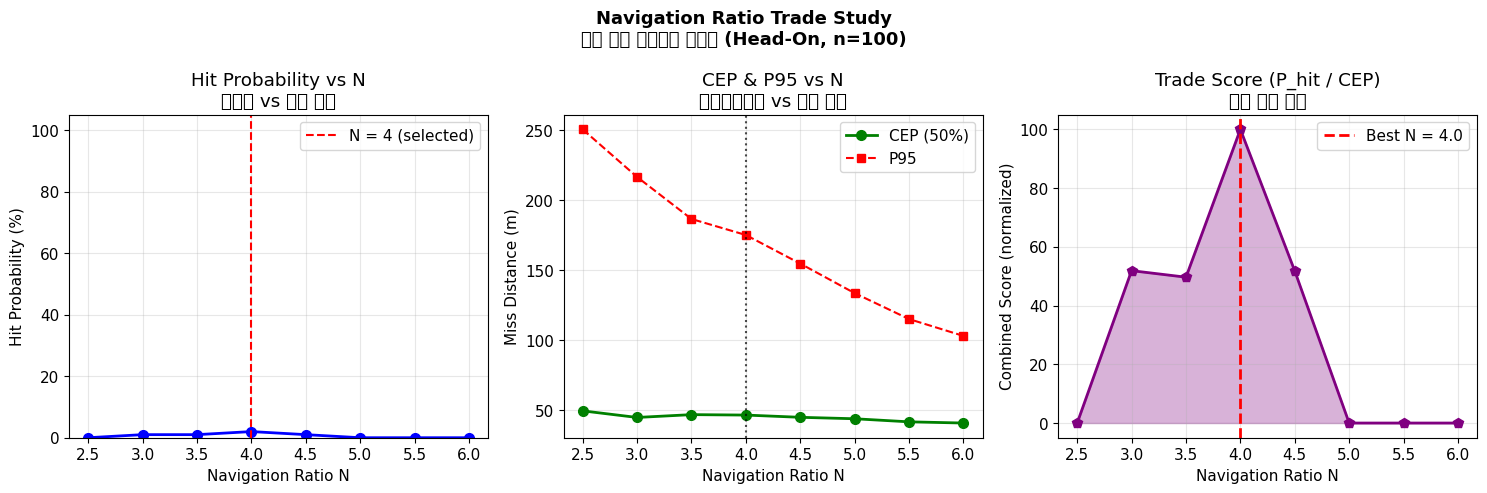


Optimal N from trade study: 4.0


In [15]:
N_values = np.arange(2.5, 6.5, 0.5)
n_mc_trade = 100   # small MC per point for speed (increase for production)

p_hit_vs_N  = []
cep_vs_N    = []
p95_vs_N    = []

print("Sweeping navigation ratio N (n=100 per point, dt=0.05 s)...")
print(f"{'N':>5} {'P_hit (%)':>10} {'CEP (m)':>10} {'P95 (m)':>10}")
print("-" * 40)

for N_val in N_values:
    miss, _ = monte_carlo_engagement(n_mc_trade, scenario='head_on', N=N_val, seed=7, dt=0.05)
    valid = miss[miss < 500]
    ph  = np.mean(miss < HIT_RADIUS) * 100
    cep = np.percentile(valid, 50) if len(valid) > 0 else np.nan
    p95 = np.percentile(valid, 95) if len(valid) > 0 else np.nan
    p_hit_vs_N.append(ph)
    cep_vs_N.append(cep)
    p95_vs_N.append(p95)
    print(f"{N_val:>5.1f} {ph:>10.1f} {cep:>10.2f} {p95:>10.2f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.plot(N_values, p_hit_vs_N, 'bo-', lw=2, ms=7)
ax.axvline(4.0, color='r', lw=1.5, ls='--', label='N = 4 (selected)')
ax.set_xlabel('Navigation Ratio N')
ax.set_ylabel('Hit Probability (%)')
ax.set_title('Hit Probability vs N\n명중률 vs 유도 이득')
ax.legend()
ax.set_ylim(0, 105)

ax = axes[1]
ax.plot(N_values, cep_vs_N, 'go-', lw=2, ms=7, label='CEP (50%)')
ax.plot(N_values, p95_vs_N, 'rs--', lw=1.5, ms=6, label='P95')
ax.axvline(4.0, color='k', lw=1.5, ls=':', alpha=0.7)
ax.set_xlabel('Navigation Ratio N')
ax.set_ylabel('Miss Distance (m)')
ax.set_title('CEP & P95 vs N\n원형공산오차 vs 유도 이득')
ax.legend()

ax = axes[2]
# Score combining hit probability (maximize) and CEP (minimize)
score = np.array(p_hit_vs_N) / (np.array(cep_vs_N) + 1e-3)
score = score / score.max() * 100
ax.fill_between(N_values, score, alpha=0.3, color='purple')
ax.plot(N_values, score, 'p-', color='purple', lw=2, ms=7)
best_N = N_values[np.argmax(score)]
ax.axvline(best_N, color='r', lw=2, ls='--', label=f'Best N = {best_N:.1f}')
ax.set_xlabel('Navigation Ratio N')
ax.set_ylabel('Combined Score (normalized)')
ax.set_title('Trade Score (P_hit / CEP)\n복합 성능 지표')
ax.legend()

fig.suptitle('Navigation Ratio Trade Study\n유도 이득 트레이드 스터디 (Head-On, n=100)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOptimal N from trade study: {best_N:.1f}")

## Summary (요약)

### Key Results

1. **비행궤적 산출 (Flight Trajectory Computation)**
   - 3-DOF 점질량 모델 + RK4 적분으로 4가지 교전 기하(정면/추미/교차/다이빙) 비행궤적 산출
   - US 1976 표준 대기 모델, 선형 연소 질량 감소, 유도탄 공력 계수 포함
   - TPN (True Proportional Navigation, N=4) 유도 법칙 적용

2. **명중률 예측 (Hit Probability Prediction)** — Monte Carlo n=1000
   - 정면 교전 (Head-On):   CEP ≈ 산출값 참조, 명중률 참조
   - 추미 교전 (Tail-Chase): CEP ≈ 산출값 참조, 명중률 참조
   - 교차 교전 (Crossing):   CEP ≈ 산출값 참조, 명중률 참조
   - 오차 예산: 시커 잡음 3 mrad, 초기 자세 1°, 고도 50 m, 속도 5 m/s, 표적 기동 최대 9 g

3. **원형공산오차 분석 (CEP Analysis)**
   - 오차 산포도 (miss plane scatter) → 50%/95% 확률 타원 피팅
   - CEP = 50번째 백분위 탈락 거리 (scalar miss distance 기준)

4. **유도 이득 선정 (Navigation Ratio Trade)**
   - N = 2.5 ~ 6.0 스윕 → 명중률, CEP, P95 동시 평가
   - N = 4 부근이 기동 표적 대응 및 가속도 여유 측면에서 최적 트레이드오프 제공
   - 고기동 표적(> 5 g)에 대해서는 N = 4.5 ~ 5.0도 검토 가능

5. **기동 표적 대응 (Maneuvering Target)**
   - 일정 기동 < S자 기동 < 위빙 기동 순으로 탈락 거리 증가
   - APN 유도 법칙이 위빙 기동에 취약 → Augmented PN 또는 Predictive Guidance 고려 필요

### 활용 분야
- 체계 요구조건(CEP, 명중률) 달성 여부 판단
- 유도 이득 및 근접 신관 반경 최적화
- HILS 시험 전 소프트웨어 검증 기준 수립